### **A3.2 Clustering**




Bienvenido al tutorial de Clustering. Veremos un poco sobre qué es, 2 métodos diferentes y cómo usarlos.




Este tutorial estará dividido en 2 secciones: k-means y agrupamiento jerárquico.




---
#### **K-means**


Comenzaremos haciendo una base de datos sintética, con 1000 datos, 2 columnas por cada observación, 3 clusters distintos y una desviación entre los clusters de 1.5. Hacemos una base de datos sintética para poder comprender un poco más el tema **K-means** antes de pasar a una base de datos real, donde los datos no se comportan tan ordenadamente como para ver patrones a simple vista.


Usaremos la función `make_blobs`, de la librería con el mismo nombre, para crear estos datos, poniéndole los datos que establecí anteriormente. Puedes agregar una semilla de aleatoriedad para que cada vez que ejecutes el código obtengas los mismos datos. Yo usé `random_state=1`. Además, debemos importar la librería a`pandas` para poder manipular los datos.



In [21]:
from sklearn.datasets import make_blobs
import pandas as pd

# Generate synthetic data
n_samples = 1000
n_features = 2
n_centers = 3
cluster_std = 1.5

X, y = make_blobs(n_samples=n_samples, centers=n_centers, n_features=n_features, cluster_std=cluster_std, random_state=1)


Para ver cómo quedaron los datos mostraremos las primeras 5 filas. Usaremos la función `display` junto con `head()` para lograrlo. Al ser una base sintética, las columnas no tienen nombre, por lo que agregaremos `feature 1` y `feature 2`, así como se puede ver en la primera línea de código. Esto lo debemos hacer antes de imprimir los datos, para que se puedan ver estos nuevos nombres que acabamos de imprimir en lo que se despliega.

In [22]:
# Display the first 5 rows of the generated features (X)
df_X = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(n_features)])
display(df_X.head())

# Display the first 5 rows of the generated labels (y)
df_y = pd.DataFrame(y, columns=['cluster_label'])
display(df_y.head())

,feature_1,feature_2
0,-3.757779,4.529142
1,-7.915752,-3.614049
2,2.886726,5.643367
3,-9.009907,-2.454996
4,-9.425992,-8.002338


,cluster_label
0,0
1,1
2,0
3,1
4,2


Ya que imprimimos las primeras 5 filas de los datos ahora visualizaremos gráficamente cómo se comportan, para ver existen claras agrupaciones que se puedan hacer. Para esto, graficaremos `feature_1` vs `feature_2`. Primero, para poder ver los datos gráficamente y crear gráficos, demos importar las librerías `matplotlib.pyplot` y `seaborn`. Los los graficaremos del mismo color, sin distinguir entre las verdaderas clases. Para crear la gráfica de dispersión usaremos `scatterplot`.

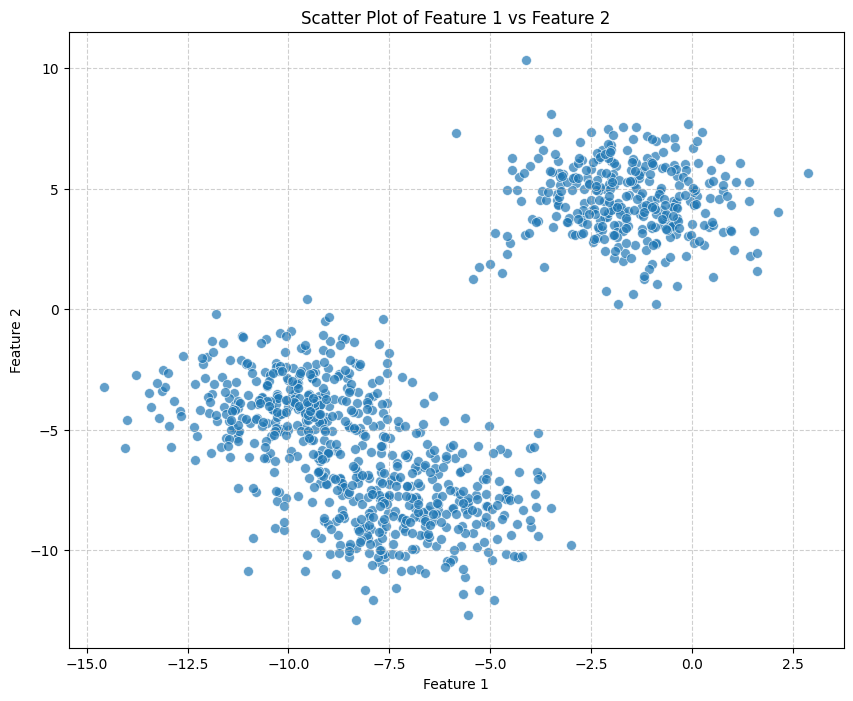

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of feature_1 vs feature_2
plt.figure(figsize=(10, 8))
sns.scatterplot(x='feature_1', y='feature_2', data=df_X, s=50, alpha=0.7)
plt.title('Scatter Plot of Feature 1 vs Feature 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Si usaste la misma semilla de aleatoriedad para crear los datos te podrás dar cuenta que parece que hay 2 grupos en los que se pueden agregar los datos. Tal vez hasta se podría decir que ese grupo grande de datos que se ve en el cuadrante 3 podría dividirse en más grupos.


Ahora, para tener una referencia de un clustering de referencia, estaremos haciendo un agrupamiento aleatorio. Para hacerlo, usaremos la librería `numpy`. También estableceremos una semilla de aleatoriedad para que los resultados sean reproducibles. Yo usaré la número 53. Tú la puedes modificar.
Como yo identifiqué 2 clusters en mi gráfica anterior, le pediré al código que clasifique en estos 2 grupos de manera aleatoria los 1000 datos (puedes modificar este número si identificaste más clusters en tus datos). Después creamos una copia del data frame y le añadimos las columnas de `random_cluster`, así como se puede ver en el código. Luego mostramos las primeras 5 filas de esta nueva tabla, así como lo hicimos hace unos pasos.


Luego, visualizaremos los datos utilizando de nuevo un gráfico de dispersión (con `scatterplot`), así como lo hicimos anteriormente. Las variables `feature_1` y `feature_2` las ponemos como los ejes `x` y `y` respectivamente. Con esto, podremos visualizar cómo se distribuyen los datos y si el cluster que se les asignó de manera aleatoria (que se puede ver con el color del punto) se parece a los grupos que habíamos identificado anteriormente.





In [24]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(53)

# Generate random labels for 2 clusters (0 or 1)
# The number of samples (n_samples) is already defined as 1000
random_cluster_labels = np.random.randint(0, 2, n_samples)

# Add these new labels to a copy of df_X for plotting
df_X_with_new_labels = df_X.copy()
df_X_with_new_labels['random_cluster'] = random_cluster_labels

# Display the first 5 rows with the new labels
display(df_X_with_new_labels.head())

,feature_1,feature_2,random_cluster
0,-3.757779,4.529142,1
1,-7.915752,-3.614049,1
2,2.886726,5.643367,1
3,-9.009907,-2.454996,1
4,-9.425992,-8.002338,1


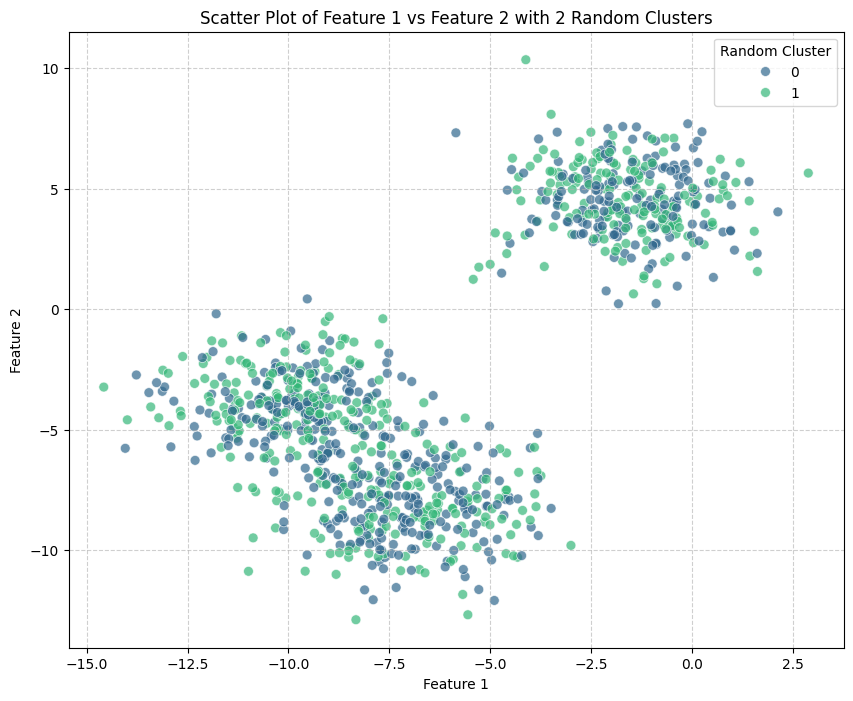

In [25]:
# Create a scatter plot of feature_1 vs feature_2, colored by the new random cluster labels
plt.figure(figsize=(10, 8))
sns.scatterplot(x='feature_1', y='feature_2', hue='random_cluster', data=df_X_with_new_labels, s=50, alpha=0.7, palette='viridis')
plt.title('Scatter Plot of Feature 1 vs Feature 2 with 2 Random Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Random Cluster')
plt.show()

Como podrás ver, en ambos grupos que se habían identificado no hay puntos de un sólo color, si no que se hay mezcla de clusters en varias zonas del gráfico. Esto nos lleva a pensar que asignar de manera aleatoria los datos a un cluster no es la manera más efectiva para hacerlo.


Para seguir confirmando esto, ahora vamos a graficar los centroides. Éstos son el punto medio entre todas las observaciones que pertenecen al mismo punto. Para obtener, usamos `groupby` para agruparlos por el `random_cluster` y después calculamos el promedio de la variable y y de la dos para cada cluster, usando `mean()`. Después usamos `.reset_index()` para reorganizar el resultado en un nuevo DataFrame. Después mostramos los resultados así como lo hemos estado haciendo.


Posteriormente, para ver de manera visual dónde quedan estos centroides, volvemos a hacer el gráfico de dispersión pero ahora añadiendo los centroides sobre la gráfica usando `plt.scatter`, representándolos como cruces (`marker='X') en color rojo.


,random_cluster,feature_1,feature_2
0,0,-6.114229,-2.717493
1,1,-6.246652,-2.308027


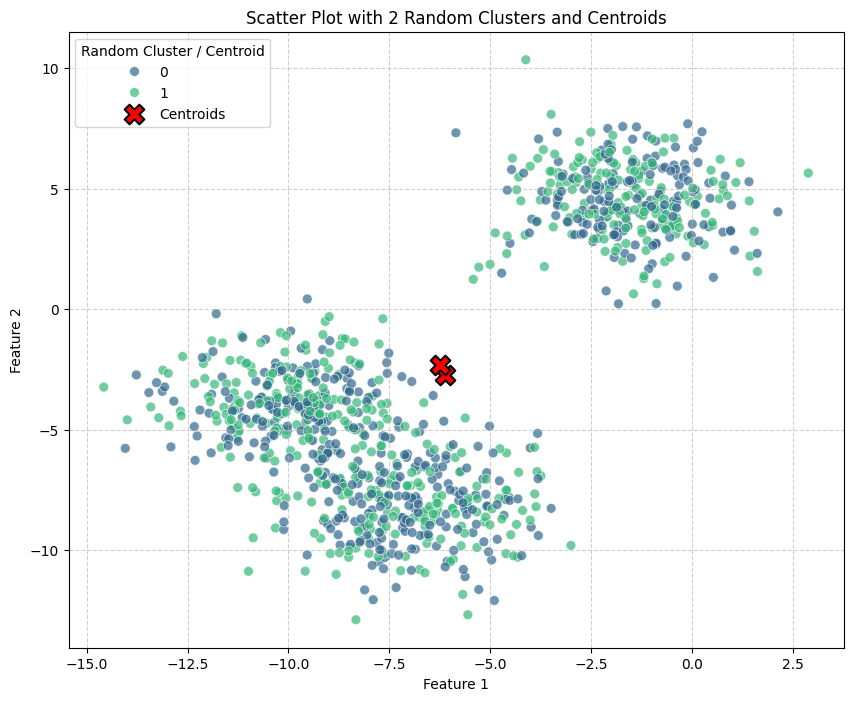

In [26]:
# Calculate centroids for the new random clusters
cluster_centroids = df_X_with_new_labels.groupby('random_cluster')[['feature_1', 'feature_2']].mean().reset_index()

# Display the calculated centroids
display(cluster_centroids)

# Create a scatter plot of feature_1 vs feature_2, colored by the new random cluster labels
plt.figure(figsize=(10, 8))
sns.scatterplot(x='feature_1', y='feature_2', hue='random_cluster', data=df_X_with_new_labels, s=50, alpha=0.7, palette='viridis')

# Overlay the centroids
plt.scatter(x=cluster_centroids['feature_1'], y=cluster_centroids['feature_2'],
            c='red', s=200, marker='X', edgecolor='black', linewidth=1.5, label='Centroids')

plt.title('Scatter Plot with 2 Random Clusters and Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Random Cluster / Centroid')
plt.show()

Idealmente, queremos que los centroides estén lo más cerca que se pueda con los puntos pertenecientes a este grupo. Y con este método de aleatoriamente asignar un cluster a cada dato podemos ver que los centroides están lejos de los puntos de su mismo grupo.


Ahora haremos manualmente una iteración de cómo funciona K-means, que es asignar cada punto al centroide más cercano y recalcular los centroides con base en esas nuevas asignaciones.


Primero, necesitamos importar la librería `cdist` para poder obtener la distancia euclidiana. Luego, tomaremos los valores (coordenadas) de los centroides que calculamos anteriormente, con la función `.values`, de la variable `cluster_centroids`. También sacamos todos las coordenadas de los puntos en un arreglo, con la misma función. Luego calculamos la distancia de los puntos, usando la función `cdist` y agregamos el parámetro `euclidean` para calcular la distancia euclidiana, que mide la distancia "directa" entre los puntos en el espacio, en cualquier número de dimensiones. Luego, en base a estas distancias se asigna un nuevo cluster a cada punto. La función `bp.argmin(distances, axis=1)` sirve para encontrar el índice del centroide más cercano, para asignarlo al cluster al que corresponde. Estos datos se agregan a la misma variable `new_random_cluster_labels` (aunque para este punto los clusters ya no se asignan de manera aleatoria), para que pueda ser un proceso iterativo hasta que se encuentre el mejor agrupamiento; hasta que los centroides dejen de cambiar significativamente.


Luego volvemos a hacer una gráfica como la que hicimos en el paso anterior, graficando los puntos coloreados por el cluster al que se asignó y los centroides de cada cluster.


New cluster labels assigned and centroids recalculated. First 5 rows of updated data:


,feature_1,feature_2,random_cluster
0,-3.757779,4.529142,1
1,-7.915752,-3.614049,0
2,2.886726,5.643367,1
3,-9.009907,-2.454996,0
4,-9.425992,-8.002338,0


New Centroids:


,random_cluster,feature_1,feature_2
0,0,-8.471666,-6.033888
1,1,-1.606159,4.491249


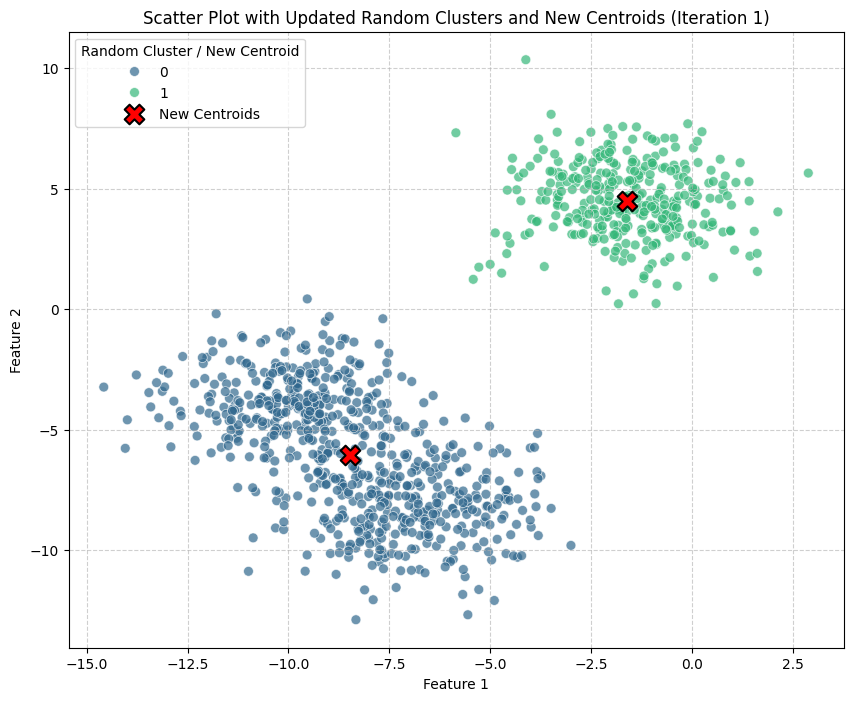

In [43]:
from scipy.spatial.distance import cdist

# Get current centroids as a NumPy array
centroids_array = cluster_centroids[['feature_1', 'feature_2']].values

# Get data points as a NumPy array
data_points = df_X_with_new_labels[['feature_1', 'feature_2']].values

# Calculate Euclidean distance from each data point to each centroid
distances = cdist(data_points, centroids_array, 'euclidean')

# Assign each data point to the cluster of the closest centroid
# The index of the minimum distance corresponds to the cluster label
new_random_cluster_labels = np.argmin(distances, axis=1)

# Update the 'random_cluster' column in df_X_with_new_labels
df_X_with_new_labels['random_cluster'] = new_random_cluster_labels

# Recalculate centroids based on the new assignments
cluster_centroids = df_X_with_new_labels.groupby('random_cluster')[['feature_1', 'feature_2']].mean().reset_index()

print("New cluster labels assigned and centroids recalculated. First 5 rows of updated data:")
display(df_X_with_new_labels.head())
print("New Centroids:")
display(cluster_centroids)

# Create a scatter plot with the updated cluster labels and new centroids
plt.figure(figsize=(10, 8))
sns.scatterplot(x='feature_1', y='feature_2', hue='random_cluster', data=df_X_with_new_labels, s=50, alpha=0.7, palette='viridis')

# Overlay the new centroids
plt.scatter(x=cluster_centroids['feature_1'], y=cluster_centroids['feature_2'],
            c='red', s=200, marker='X', edgecolor='black', linewidth=1.5, label='New Centroids')

plt.title('Scatter Plot with Updated Random Clusters and New Centroids (Iteration 1)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Random Cluster / New Centroid')
plt.show()

Yo ejecuté este bloque de código aproximadamente 4 veces, basándome en la gráfica hasta ver que los centroides ya no variaban tanto entre cada iteración. Tú puedes ejecutar tú código hasta que veas que ya no hay diferencias significativas entre los centroides de tus clusters.


Esto que acabamos de hacer, así como dije anteriormente, es en esencia como funciona k-means, sólo que lo hicimos de manera manual en vez de usar la función disponible, para poder entender mejor cómo funciona este método.


Ahora, ya que tenemos este entendimiento, pasaremos a datos reales.
Para esto, cargaremos la base de datos `NCI60`. Pero primero, debemos instalar el paquete ISLP. Ejecuta esta línea de código `!pip install ISLP` antes de cargar la base de datos. Puede tardar un poco más de lo habitual. Ya que se haya instalado este paquete, importaremos los datos que anteriormente mencioné, importando la librería `load_data` y cargando `NCI60`. Estos son datos con 64 líneas celulares cancerosas (muestras), abarcando diferentes tipos de cáncer. Y tiene 6830 genes (variables). También incluye el tipo de cáncer al que pertenece la muestra. Guardaremos los datos pertenecientes a `X` en una variable y la variable objetivo en `Y`. Los datos guardados en `X` los convertimos en un DataFrame para manejarla más fácilmente, con la función `pd.DataFrame`.


Para confirmar toda esta información, imprimiremos el tamaño de la base de datos, con la función `shape()`, tanto para los datos en la variable que guardamos en `X` y los datos que guardamos en la variable `y`. También desplegamos las primeras 5 líneas del conjunto de `X` con `head()`. De igual manera, imprimimos la cantidad de valores que pertenecen a cada clase, contanto los valores con `value_count` en la variable `y`.

In [28]:
!pip install ISLP

In [29]:
import pandas as pd
from ISLP import load_data

# Load the NCI60 dataset
nci60_data = load_data('NCI60')

# The NCI60 dataset from ISLP is a dictionary-like object with 'data' and 'labels' keys
X_nci = pd.DataFrame(nci60_data['data']) # Convert X_nci to a Pandas DataFrame
y_nci = nci60_data['labels']

print("NCI60 Dataset Loaded.")

# Display features (first 5 rows)
print("\nFeatures (X_nci) - first 5 rows:")
display(X_nci.head())

# Display shape of features and labels
print("\nShape of features (X_nci):", X_nci.shape)
print("Shape of labels (y_nci):", y_nci.shape)

# Count and display unique labels
print("\nUnique labels and their counts (y_nci):")
display(y_nci.value_counts())

NCI60 Dataset Loaded.

Features (X_nci) - first 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,6820,6821,6822,6823,6824,6825,6826,6827,6828,6829
0,0.300000,1.180000,0.550000,1.140000,-0.265000,-7.000000e-02,0.350000,-0.315000,-0.450000,-0.654980,...,-0.990020,0.000000,0.030000,-0.175000,0.629981,-0.030000,0.000000,0.280000,-0.340000,-1.930000
1,0.679961,1.289961,0.169961,0.379961,0.464961,5.799610e-01,0.699961,0.724961,-0.040039,-0.285019,...,-0.270058,-0.300039,-0.250039,-0.535039,0.109941,-0.860039,-1.250049,-0.770039,-0.390039,-2.000039
2,0.940000,-0.040000,-0.170000,-0.040000,-0.605000,0.000000e+00,0.090000,0.645000,0.430000,0.475019,...,0.319981,0.120000,-0.740000,-0.595000,-0.270020,-0.150000,0.000000,-0.120000,-0.410000,0.000000
3,0.280000,-0.310000,0.680000,-0.810000,0.625000,-1.387779e-17,0.170000,0.245000,0.020000,0.095019,...,-1.240020,-0.110000,-0.160000,0.095000,-0.350019,-0.300000,-1.150010,1.090000,-0.260000,-1.100000
4,0.485000,-0.465000,0.395000,0.905000,0.200000,-5.000000e-03,0.085000,0.110000,0.235000,1.490019,...,0.554980,-0.775000,-0.515000,-0.320000,0.634980,0.605000,0.000000,0.745000,0.425000,0.145000



Shape of features (X_nci): (64, 6830)
Shape of labels (y_nci): (64, 1)

Unique labels and their counts (y_nci):


,count
label,
RENAL,9
NSCLC,9
MELANOMA,8
BREAST,7
COLON,7
LEUKEMIA,6
OVARIAN,6
CNS,5
PROSTATE,2


Podrás confirmar que sí hay sólo 64 observaciones y 6830 variables. También podrás notar que hay 14 posibles etiquetas para el tipo de cáncer y que hay un desbalance entre las clases de cáncer.

Ahora, así como hicimos anteriormente, vamos a graficar algunos pares de variables para ver si podemos identificar clusters. Primero definiremos las variables con las que haremos las combinaciones para estas gráficas, usando la función `.iloc[:, [0,1,2]]`, donde los dos puntos indica que se seleccionan todas las filas de la base de datos y lo que está adentro del otro bracket son las columnas que se están seleccionando (qué son las primeras 3 columnas). Para graficar los puntos, volvemos a usar la función `scatterplot`, agregando algunos detalles para mejor visualización y comprensión de los datos en la gráfica, así como puedes ver en las líneas de código en el siguiente bloque.

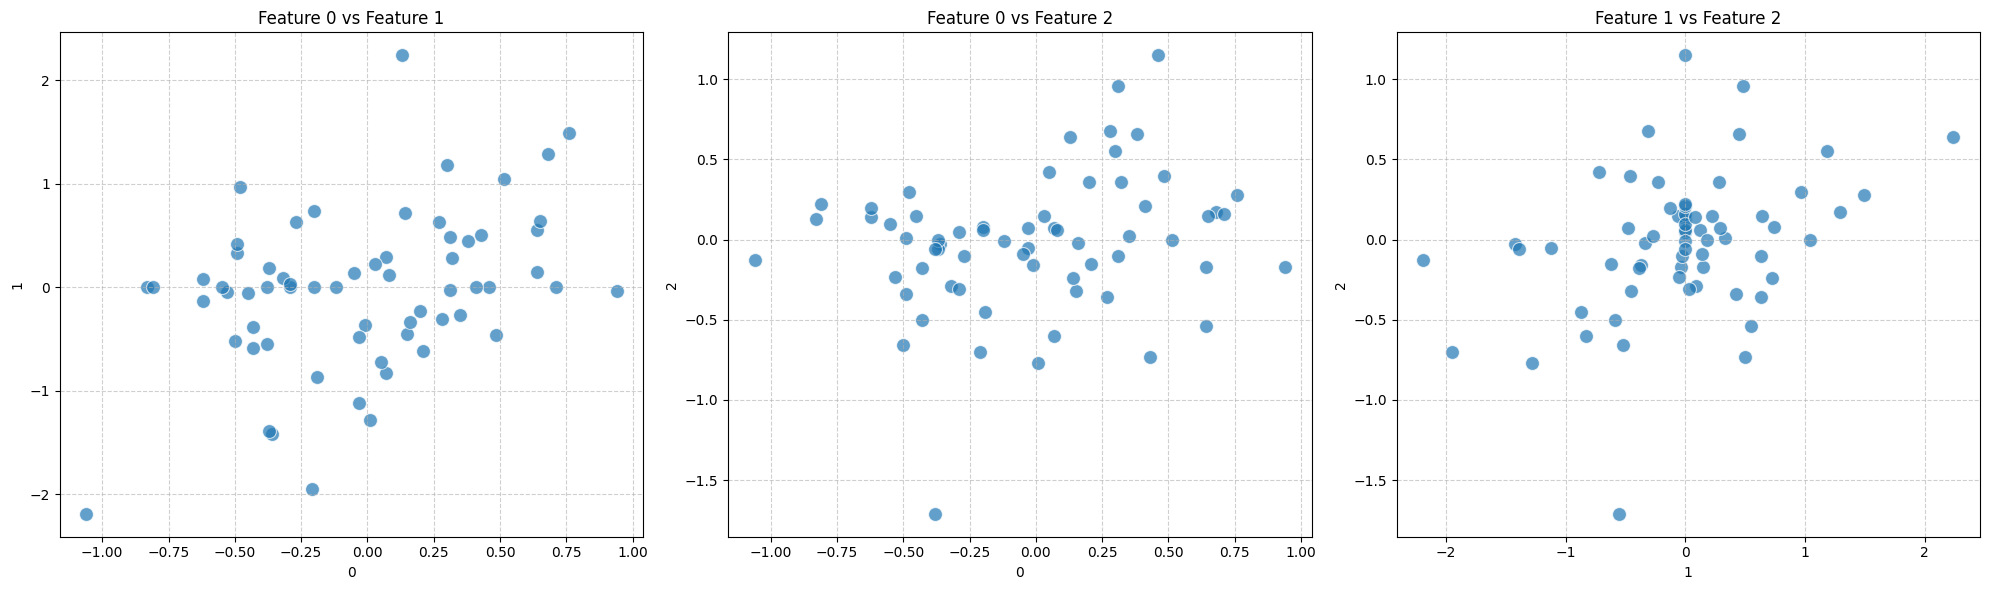

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar algunas características para graficar. Usemos las primeras 3 como ejemplo.
# Asumiendo que X_nci es un DataFrame con columnas numéricas
features_to_plot = X_nci.iloc[:, [0, 1, 2]]

# Crear un DataFrame para graficar, usando solo las características seleccionadas
df_plot = features_to_plot.copy()

# Graficar pares de características
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Graficar característica 0 vs característica 1
sns.scatterplot(x=df_plot.columns[0], y=df_plot.columns[1], data=df_plot, s=100, alpha=0.7, ax=axes[0])
axes[0].set_title(f'Feature {df_plot.columns[0]} vs Feature {df_plot.columns[1]}')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Graficar característica 0 vs característica 2
sns.scatterplot(x=df_plot.columns[0], y=df_plot.columns[2], data=df_plot, s=100, alpha=0.7, ax=axes[1])
axes[1].set_title(f'Feature {df_plot.columns[0]} vs Feature {df_plot.columns[2]}')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Graficar característica 1 vs característica 2
sns.scatterplot(x=df_plot.columns[1], y=df_plot.columns[2], data=df_plot, s=100, alpha=0.7, ax=axes[2])
axes[2].set_title(f'Feature {df_plot.columns[1]} vs Feature {df_plot.columns[2]}')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Como podrás ver, a diferencia de los datos con los que estuvimos trabajando anteriormente, aquí no se pueden identificar claramente cuántos clusters hay. Considerando que tenemos 6830 variables, en un plano 2D explica muy poco de lo que todas estas juntas tienen de información.


Diremos que hay 5 clusters, aunque realmente no se identifiquen bien. En base a esto, aplicaremos K-means clustering a este conjunto de datos.


Primero, lo haremos sin utilizar PCA.


Antes de comenzar, necesitamos escalar los datos, ya que este método se basa en distancias y no queremos que las diferentes escalas de las variables afecten. Para esto, importamos la librería `Standard Scaler` y `KMeans` para usarla más adelante para hacer el agrupamiento. Inicializamos el scaler con `StandardScaler()`. Luego ajustamos los datos de `X` y luego los transformamos usando `scaler.fit_transform`.







In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Escalar los datos de X_nci
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nci)

print("Datos X_nci escalados.")

Datos X_nci escalados.


Ahora que ya tenemos los datos escalados podemos pasar el clustering con k-means sin PCA. Para esto, vamos a usar la función `KMeans`, dando como parámetros 5 clusters y 20 iteraciones y agregando una semilla de aleatoriedad (yo usé la 42). Luego, con `kmeans_no_pca.fit(X_scaled)` lo que hace es que se entrena el modelo con estos datos, en donde se realiza el proceso de K-means iterativamente: se asigna a cada punto el centroide más cercano y se recalculan los centroides como el promedio de los puntos asignados. Después obtenemos los centros de los clusters. Por último, imprimimos las primeras 5 etiquetas de cluster, además de la forma de los centroides, así como se puede observar en el bloque de código.





In [32]:
from sklearn.cluster import KMeans
import numpy as np

# Aplicar K-Means con 5 clusters y n_init entre 10 y 50 (usaremos 20)
kmeans_no_pca = KMeans(n_clusters=5, n_init=20, random_state=42)
kmeans_no_pca.fit(X_scaled)

# Obtener las etiquetas de los clusters
cluster_labels_kmeans_no_pca = kmeans_no_pca.labels_

# Obtener los centros de los clusters en el espacio original de alta dimensión
cluster_centers_original_no_pca = kmeans_no_pca.cluster_centers_

print("K-Means clustering completado con 5 clusters (sin PCA).")
print("Primeras 5 etiquetas de cluster:")
display(cluster_labels_kmeans_no_pca[:5])

print("Forma de los centroides de los clusters (sin PCA):")
print(cluster_centers_original_no_pca.shape)

K-Means clustering completado con 5 clusters (sin PCA).
Primeras 5 etiquetas de cluster:


array([3, 3, 3, 3, 3], dtype=int32)

Forma de los centroides de los clusters (sin PCA):
(5, 6830)


Como podemos ver, tenemos 5 centroides en un espacio de 6830 dimensiones. Son muchas; algunas puede que ya ni siquiera estén aportando información relevante. Es por eso que ahora debemos aplicar PCA, para reducir las dimensiones.


Para esto, debemos comenzar importando la librería `PCA`. Reduciremos la dimensionalidad a 3 componentes para poder visualizarlos `(n_components=3)`. Luego ajustamos el modelo  y transformamos los datos con `fit_transform(X_scaled)`. Después, crearemos un DataFrame con la función del mismo nombre con los componentes PCA, además de añadir las etiquetas originales con `Original Label` de `y_nci`. Por último, para confirmar que se haya hecho todo correctamente, imprimimos los primeros 5 valores con `display(df_pca_3d.head())`.


También, así como hicimos gráficas de dispersión para las primeras variables hace unos pasos, ahora también haremos lo mismo pero con las primeras 3 componentes de PCA, para ver si podemos identificar posibles clusters.
Puedes seguir los mismos pasos que usamos anteriormente, sólo cambiando las variables.





PCA aplicado a los datos escalados con 3 componentes.


,Principal Component 1,Principal Component 2,Principal Component 3,Original Label
0,19.838000,-3.564529,-9.797443,CNS
1,23.089172,-6.447730,-13.469009,CNS
2,27.456085,-2.463868,-3.533559,CNS
3,42.816777,9.769895,-0.892195,RENAL
4,55.418527,5.206971,-21.102528,BREAST


/tmp/ipykernel_10266/971766827.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=df_pca_3d, s=100, alpha=0.7, ax=axes[0], palette='tab20')
/tmp/ipykernel_10266/971766827.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
/tmp/ipykernel_10266/971766827.py:27: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Principal Component 1', y='Principal Component 3', data=df_pca_3d, s=100, alpha=0.7, ax=axes[1], palette='tab20')
/tmp/ipykernel_10266/971766827.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axe

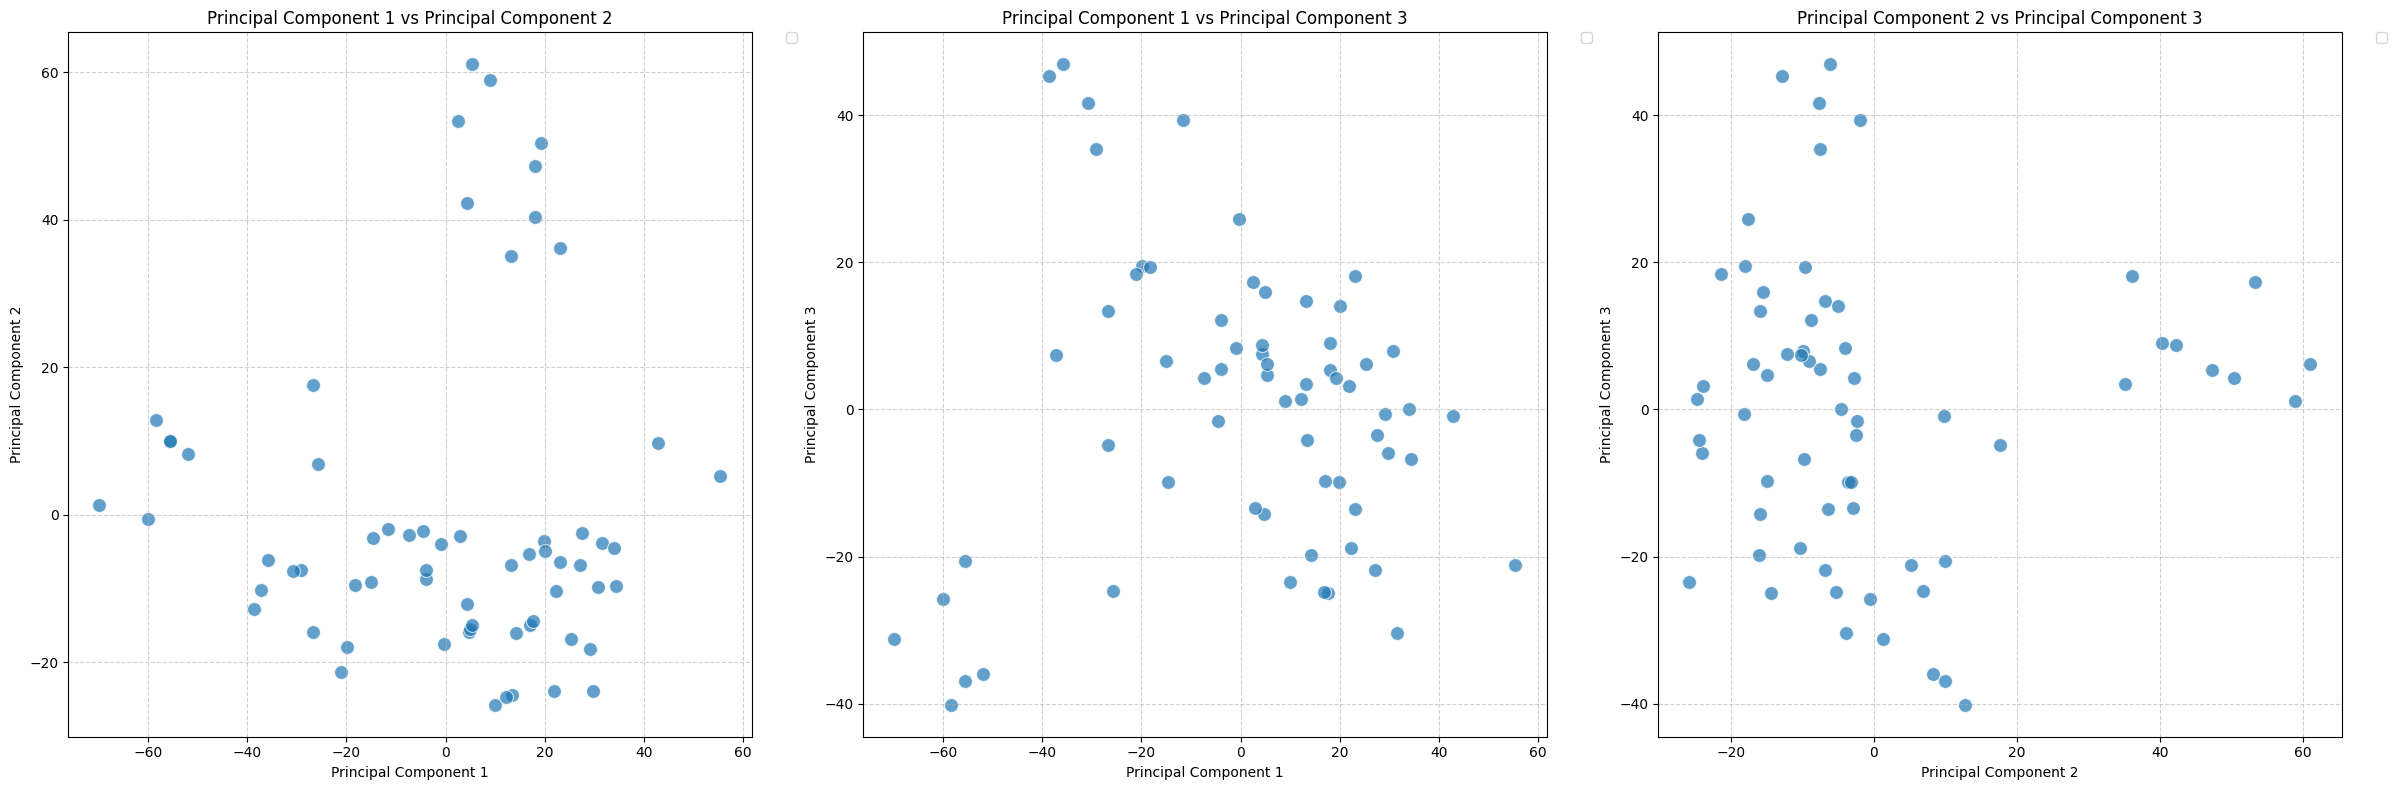

In [33]:
from sklearn.decomposition import PCA

# Aplicar PCA para reducir la dimensionalidad a 3 componentes para visualización
pca_3_components = PCA(n_components=3)
X_pca_3d = pca_3_components.fit_transform(X_scaled)

# Crear un DataFrame para los componentes PCA
df_pca_3d = pd.DataFrame(data = X_pca_3d, columns = ['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])

# Añadir las etiquetas originales (y_nci) para colorear los gráficos
df_pca_3d['Original Label'] = y_nci

print("PCA aplicado a los datos escalados con 3 componentes.")
display(df_pca_3d.head())


# Visualizar los pares de componentes principales
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# PC1 vs PC2
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=df_pca_3d, s=100, alpha=0.7, ax=axes[0], palette='tab20')
axes[0].set_title('Principal Component 1 vs Principal Component 2')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# PC1 vs PC3
sns.scatterplot(x='Principal Component 1', y='Principal Component 3', data=df_pca_3d, s=100, alpha=0.7, ax=axes[1], palette='tab20')
axes[1].set_title('Principal Component 1 vs Principal Component 3')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# PC2 vs PC3
sns.scatterplot(x='Principal Component 2', y='Principal Component 3', data=df_pca_3d, s=100, alpha=0.7, ax=axes[2], palette='tab20')
axes[2].set_title('Principal Component 2 vs Principal Component 3')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

Como te podrás dar cuenta, aquí tampoco parece que se puedan identificar claramente los clusters. La razón es la misma de porqué en las gráficas de variables tampoco se veían: con tantos componentes (6830) y gráficas en un plano 2D no es posible ver realmente cómo se podrían agrupar los datos.


Ahora, para saber cuántos componentes usar y conservar la mayor cantidad de información posible, graficaremos la varianza explicada y la varianza explicada acumulada.
Para esto, volveremos a aplicar PCA pero sin definir cantidad de componentes (obtendrá todos los componentes posibles). Hacemos los mismos dos pasos que en el bloque anterior. Después calculamos la varianza explicada por cada componente con la función `.explained_variance_ratio` y luego calculamos la varianza acumulada explicada con `np.cumsum` de la variable que acabamos de calcular (varianza acumulada individual).


Después de hacer esto, creamos la gráfica con la función `plot` con la varianza explicada individual y luego con la varianza explicada acumulada. Ambas serán graficadas en la misma figura. Luego, para tenerlo por escrito, imprimimos la cantidad de componentes que se necesitan para explicar cierto porcentaje de la varianza de los datos. En este caso, yo imprimí los componentes necesarios para imprimir el 90, 95 y 99 por ciento de la varianza de los datos. Usamos la función `np.argmax` para que la primera vez que se cumple la condición que le estamos dando (i.e. la primera vez que se llega a 0.99 de la varianza explicada acumulada) devuelva ese valor. Pero como los índices inician en 0, agregamos ese `+1` ya que queremos la cantidad de componentes.





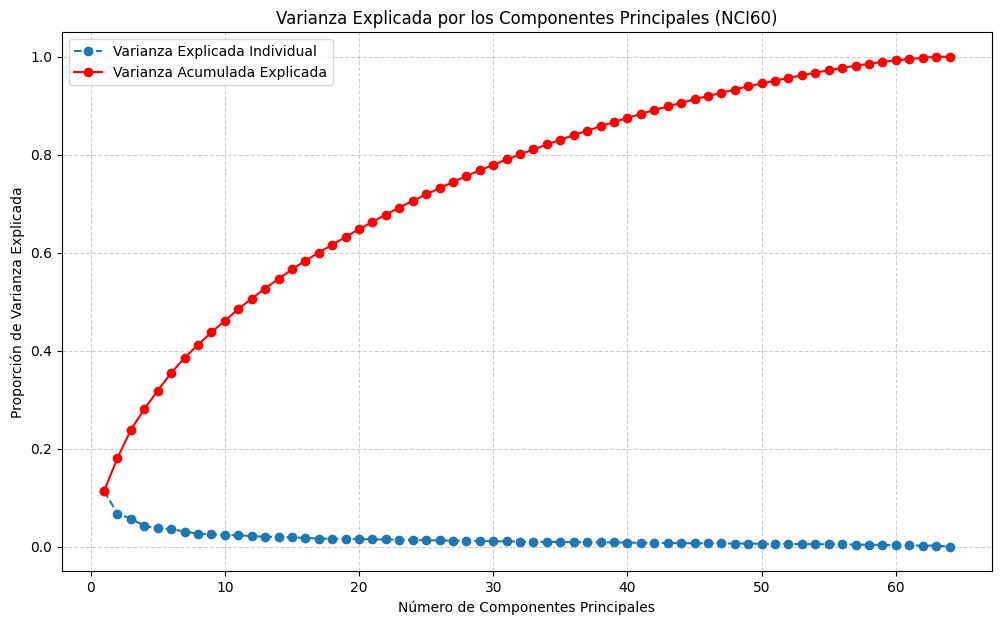

El 90% de la varianza es explicada por 44 componentes.

El 95% de la varianza es explicada por 51 componentes.

El 99% de la varianza es explicada por 60 componentes.


In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA con todos los componentes posibles para analizar la varianza explicada
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Calcular la varianza explicada por cada componente principal
explained_variance_ratio = pca_full.explained_variance_ratio_

# Calcular la varianza acumulada explicada
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Crear la gráfica de varianza explicada
plt.figure(figsize=(12, 7))

plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Varianza Explicada Individual')
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='red', label='Varianza Acumulada Explicada')

plt.title('Varianza Explicada por los Componentes Principales (NCI60)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print(f"El 90% de la varianza es explicada por {np.argmax(cumulative_explained_variance >= 0.90) + 1} componentes.\n")
print(f"El 95% de la varianza es explicada por {np.argmax(cumulative_explained_variance >= 0.95) + 1} componentes.\n")
print(f"El 99% de la varianza es explicada por {np.argmax(cumulative_explained_variance >= 0.99) + 1} componentes.")

Como podrás ver, para la varianza individual, conforme se va aumentando el número de componentes, explica menos varianza. De igual manera, podrás notar que con  aproximadamente con 15 componentes se puede explicar más del 50% de la información. Si hasta ahora has utilizado las mismas semillas de aleatoriedad también habrás obtenido que con 44 componentes se puede explicar el 90% de la varianza.


En mi caso, decidiré quedarme con esos 44 componentes que explican el 90% de la varianza en los datos, pero tú puedes cambiar la cantidad de componentes a usar para implementar el método de k-means. Volveremos a aplicar PCA a los datos escalados de `X` pero ahora especificaremos que sólo queremos 44 componentes con `n_components=44`. Después seguiremos los mismos pasos que usamos anteriormente para implementar k-means.


Posteriormente, para poder visualizar cómo quedaron los componentes principales, de la variable donde se guardaron los 44 componentes, sacamos los primeros 3, con `[:, :3]` (todas las filas de las primeras 3 columnas). Luego creamos un DataFrame con esos componentes para poder interpretarlos mejor. Luego indicamos a qué cluster pertenece cada punto, sólo de los primeros 3 componentes. Luego, calculamos los centroides de cada punto, así como lo hicimos anteriormente; primero agrupamos por cluster con `groupby` y luego sacamos el promedio de estos datos, sólo para estos 3 componentes. Luego imprimimos las primeras 5 líneas de ambas tablas.


Después, así como lo hicimos anteriormente, vamos a crear las gráficas para visualizar cómo quedaron los clusters y sus centroides. Vamos a hacer 3 gráficas, comparando 2 componentes (del 1 al 3). Usaremos la función `scatterplot` y agregaremos los centroides con `scatter` y agregamos las componentes `x` y `y` (que son los centroides calculados para los 3 componentes que usamos anteriormente). Definimos que el centroide se marque con una X con el comando `marker = X`.


Usamos `plt.tight_layout` para mostrar las 3 gráficas una a lado de la otra.

In [35]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicar PCA para reducir la dimensionalidad a 44 componentes
pca_44_components = PCA(n_components=44)
X_pca_44d = pca_44_components.fit_transform(X_scaled)

print("PCA aplicado a los datos escalados con 44 componentes.")
print("Forma de los datos PCA (44 componentes):", X_pca_44d.shape)

# Aplicar K-Means con 5 clusters a los datos PCA (44 componentes)
kmeans_44d = KMeans(n_clusters=5, n_init=20, random_state=42)
kmeans_44d.fit(X_pca_44d)

# Obtener las etiquetas de los clusters
cluster_labels_kmeans_44d = kmeans_44d.labels_

print("K-Means clustering completado con 5 clusters en 44 componentes PCA.")

# Obtener los primeros 3 componentes principales para visualización
X_pca_for_plot = X_pca_44d[:, :3]

# Crear un DataFrame para los componentes PCA (primeros 3) y las etiquetas de K-Means
df_pca_plot_kmeans = pd.DataFrame(data = X_pca_for_plot, columns = ['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])
df_pca_plot_kmeans['KMeans Cluster (44 PCA)'] = cluster_labels_kmeans_44d

# Calcular los centroides de los clusters en el espacio de 3 componentes principales
cluster_centers_3d_pca = df_pca_plot_kmeans.groupby('KMeans Cluster (44 PCA)')[['Principal Component 1', 'Principal Component 2', 'Principal Component 3']].mean().reset_index()

print("Primeras 5 filas del DataFrame para visualización:")
display(df_pca_plot_kmeans.head())
print("Centroides de los clusters (en 3 componentes PCA):")
display(cluster_centers_3d_pca.head())

PCA aplicado a los datos escalados con 44 componentes.
Forma de los datos PCA (44 componentes): (64, 44)
K-Means clustering completado con 5 clusters en 44 componentes PCA.
Primeras 5 filas del DataFrame para visualización:


,Principal Component 1,Principal Component 2,Principal Component 3,KMeans Cluster (44 PCA)
0,19.838044,-3.555587,-9.812391,1
1,23.089214,-6.441480,-13.478239,1
2,27.456112,-2.465166,-3.533100,1
3,42.816801,9.768353,-0.890066,1
4,55.418531,5.198909,-21.094536,1


Centroides de los clusters (en 3 componentes PCA):


,KMeans Cluster (44 PCA),Principal Component 1,Principal Component 2,Principal Component 3
0,0,-16.662632,-13.236101,16.754542
1,1,16.146396,-9.504589,-6.442228
2,2,12.507756,47.199340,8.168900
3,3,-54.018470,8.470863,-27.901187
4,4,-29.197914,-7.143266,43.319636


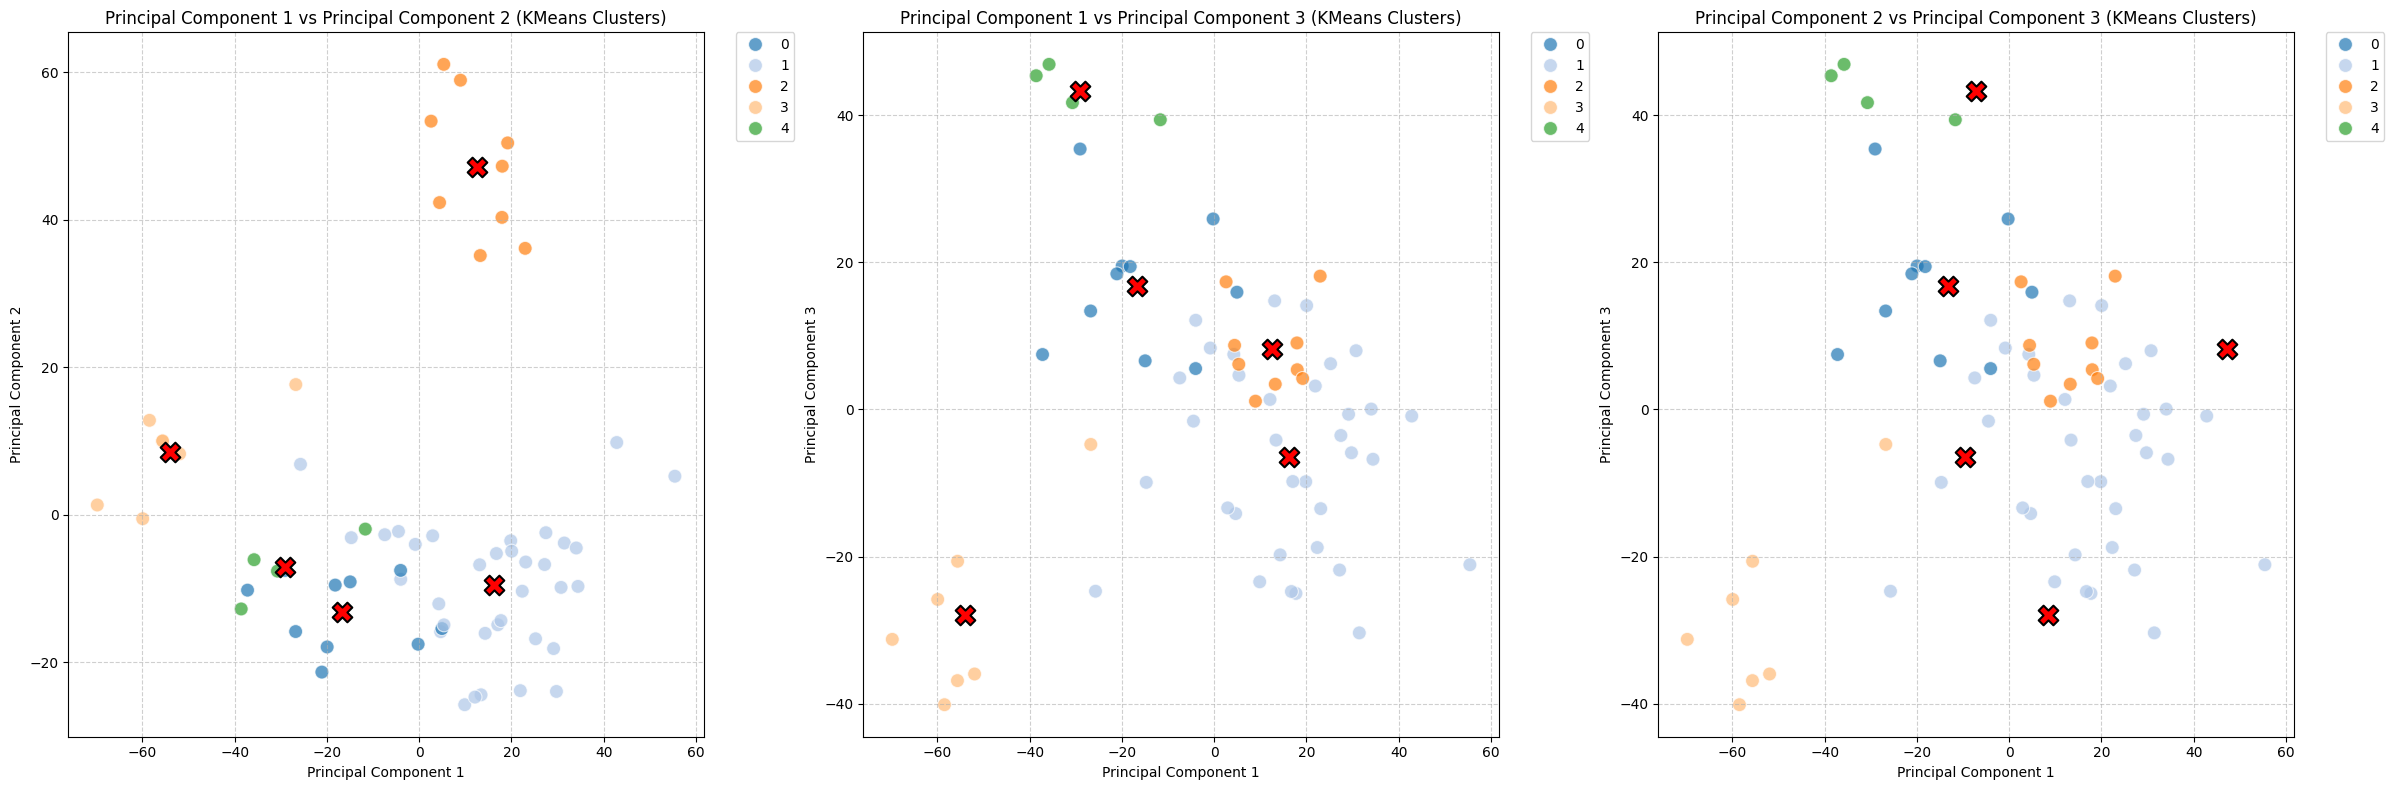

In [36]:
# Visualizar los pares de componentes principales coloreados por los clusters de K-Means
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# PC1 vs PC2
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='KMeans Cluster (44 PCA)', data=df_pca_plot_kmeans, s=100, alpha=0.7, ax=axes[0], palette='tab20')
axes[0].set_title('Principal Component 1 vs Principal Component 2 (KMeans Clusters)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# Overlay centroids
axes[0].scatter(x=cluster_centers_3d_pca['Principal Component 1'], y=cluster_centers_3d_pca['Principal Component 2'],
            c='red', s=200, marker='X', edgecolor='black', linewidth=1.5, label='Centroids')

# PC1 vs PC3
sns.scatterplot(x='Principal Component 1', y='Principal Component 3', hue='KMeans Cluster (44 PCA)', data=df_pca_plot_kmeans, s=100, alpha=0.7, ax=axes[1], palette='tab20')
axes[1].set_title('Principal Component 1 vs Principal Component 3 (KMeans Clusters)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# Overlay centroids
axes[1].scatter(x=cluster_centers_3d_pca['Principal Component 1'], y=cluster_centers_3d_pca['Principal Component 3'],
            c='red', s=200, marker='X', edgecolor='black', linewidth=1.5)

# PC2 vs PC3
sns.scatterplot(x='Principal Component 1', y='Principal Component 3', hue='KMeans Cluster (44 PCA)', data=df_pca_plot_kmeans, s=100, alpha=0.7, ax=axes[2], palette='tab20')
axes[2].set_title('Principal Component 2 vs Principal Component 3 (KMeans Clusters)')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# Overlay centroids
axes[2].scatter(x=cluster_centers_3d_pca['Principal Component 2'], y=cluster_centers_3d_pca['Principal Component 3'],
            c='red', s=200, marker='X', edgecolor='black', linewidth=1.5)

plt.tight_layout()
plt.show()

Como podrás ver, tampoco están tan definidos los clusters en este caso. Puede que uno o dos clusters parezcan más identificables pero el resto no parecerían reconocerse del todo. Pero esto, de nuevo, se debe a que sólo estamos viendo gráficas en 2 dimensiones, cuando realmente hay muchos más componentes (dimensiones), que si las pudiéramos visualizar, probablemente estos clusters tendrían más sentido.





Para evaluar la relación entre las clases originales de los tipos de cáncer y los clusters asignados por K-means, crearemos una tabla de clases vs clusters. Esta tabla nos permitirá ver cuántas muestras de cada tipo de cáncer cayeron en cada cluster y poder entender un poco más cómo se comportan.

In [40]:
# Crear una tabla de contingencia para comparar las etiquetas originales con las etiquetas de cluster de K-Means
# Usaremos las etiquetas originales de 'y_nci' y las etiquetas de cluster obtenidas de K-Means (cluster_labels_kmeans_44d)

contingency_table = pd.crosstab(index=y_nci['label'], columns=cluster_labels_kmeans_44d,
                                rownames=['Original Label'], colnames=['KMeans Cluster (44 PCA)'])

print("Tabla de contingencia (Clases Originales vs Clusters K-Means):")
display(contingency_table)

Tabla de contingencia (Clases Originales vs Clusters K-Means):


KMeans Cluster (44 PCA),0,1,2,3,4
Original Label,,,,,
BREAST,0,3,2,0,2
CNS,0,5,0,0,0
COLON,7,0,0,0,0
K562A-repro,0,0,0,1,0
K562B-repro,0,0,0,1,0
LEUKEMIA,0,1,0,5,0
MCF7A-repro,0,0,0,0,1
MCF7D-repro,0,0,0,0,1
MELANOMA,0,1,7,0,0


Podrás ver que hay ciertos tipos de cáncer que sólo pertenecen a un cluster, como el cáncer renal, de próstata, de colon, entre otros. Esto puede nos indica que hay ciertos tipos de cáncer que se pueden agrupar de manera muy consistente en un sólo cluster. Esto podría ayudar para enfocarse en qué tienen en común estos tipos de cáncer que pertenecen a un sólo cluster y poder identificar posibles causas en común o aplicar tratamientos que estén ayudando para un tipo de cáncer que está dentro del mismo grupo.


Ahora, vamos a identificar los 50 genes más diferenciales entre el cluster 0 y el cluster 1 y visualizarlos en un mapa de calor. Primero, filtraremos los datos escalados para incluir solo las muestras de estos dos clusters. Luego, calcularemos la expresión media de cada gen para cada uno de estos clusters y encontraremos los 50 genes con la mayor diferencia absoluta en expresión entre ellos. Finalmente, crearemos un mapa de calor con estos genes y muestras. Luego debemos calcular el promedio de expresión de cada gen dentro de cada cluster, con `np.mean`. Después, calculamos cuánto difiere cada gen entre cluster, pero usando el valor absoluto (`np.abs`), restando la media del gen dentro del cluster 0 menos la media del gen dentro del cluster 1. Por último, los ordenamos en orden para tener genes con más diferencia y sólo nos quedamos con los primeros 30 valores, usando la función `np.argsort` y `[:50]` respectivamente.


Luego, pasamos los nombres de las columnas a lo que acabamos de calcular, usando la función `X.nci.columns[]`. Usamos los genes que cambian más para que en el heatmap se pueda ver de manera más clara esta distinción entre clusters. Luego haremos el heatmap con `sns.heatmap`, graficando Genes Diferenciales vs Etiquetas de Cluster. Antes debemos ordenar los datos por cluster, para poder visualizarlos mejor en el mapa de calor, con `sort_values(by='Cluster')`









In [37]:
# Identificar las etiquetas de los clusters 0 y 1
cluster_0_indices = np.where(cluster_labels_kmeans_44d == 0)[0]
cluster_1_indices = np.where(cluster_labels_kmeans_44d == 1)[0]

# Filtrar los datos escalados para solo los clusters 0 y 1
X_cluster_0 = X_scaled[cluster_0_indices, :]
X_cluster_1 = X_scaled[cluster_1_indices, :]

# Calcular la expresión media de cada gen para el cluster 0 y el cluster 1
mean_expression_cluster_0 = np.mean(X_cluster_0, axis=0)
mean_expression_cluster_1 = np.mean(X_cluster_1, axis=0)

# Calcular la diferencia absoluta en la expresión media para cada gen
difference_in_expression = np.abs(mean_expression_cluster_0 - mean_expression_cluster_1)

# Obtener los índices de los 50 genes más diferenciales
top_50_differential_genes_indices = np.argsort(difference_in_expression)[::-1][:50]

# Seleccionar los nombres de las columnas para los genes diferenciales
top_50_gene_names = X_nci.columns[top_50_differential_genes_indices]

print(f"Se identificaron {len(top_50_differential_genes_indices)} genes diferenciales entre los clusters 0 y 1.")

Se identificaron 50 genes diferenciales entre los clusters 0 y 1.


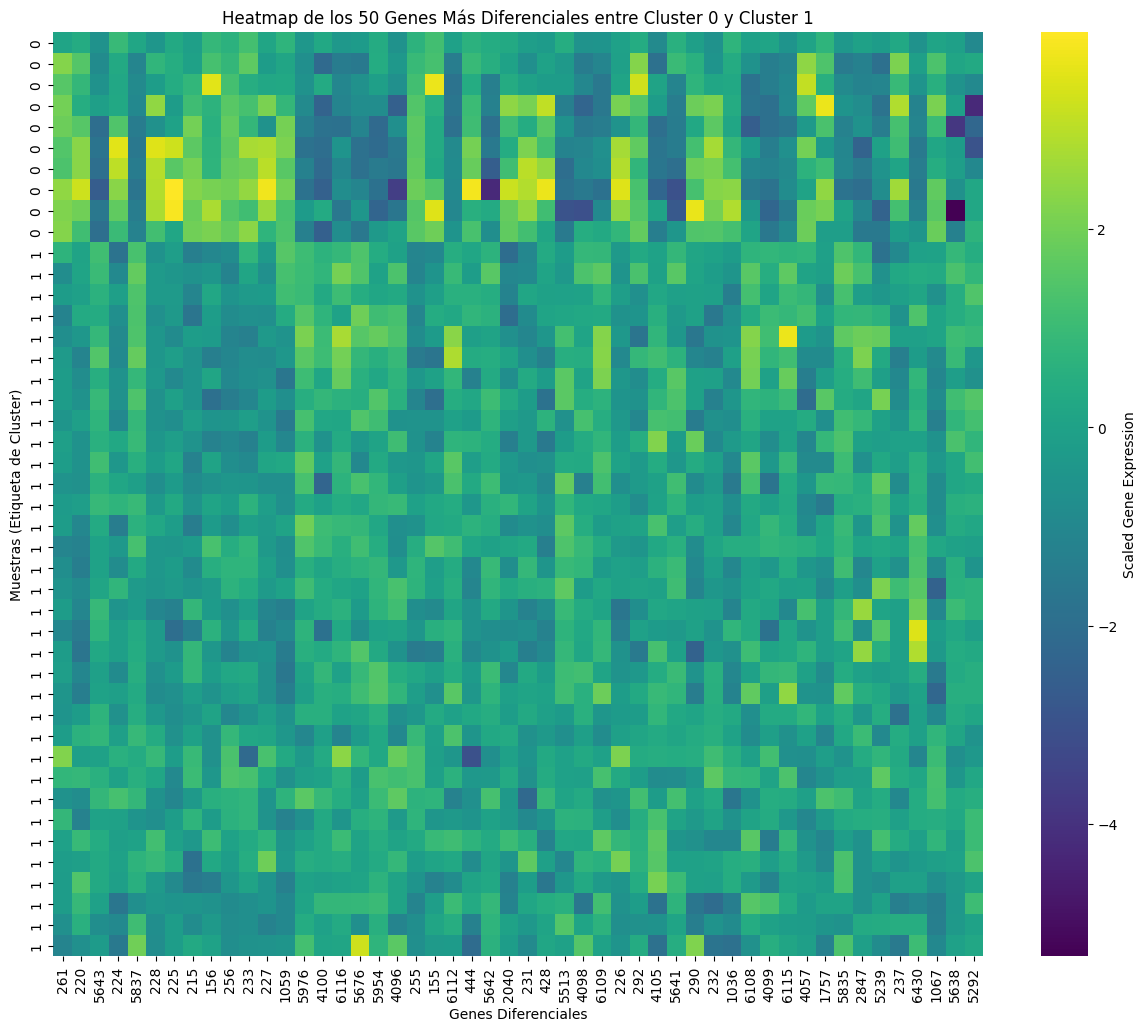

In [38]:
# Preparar los datos para el heatmap
# Combinar las muestras de ambos clusters y seleccionar solo los genes diferenciales

# Filtrar X_scaled para las muestras de cluster 0 y 1
all_relevant_indices = np.concatenate((cluster_0_indices, cluster_1_indices))
X_relevant_samples = X_scaled[all_relevant_indices, :]

# Seleccionar solo los 50 genes diferenciales
heatmap_data = X_relevant_samples[:, top_50_differential_genes_indices]

# Crear un DataFrame para el heatmap con las etiquetas de cluster y nombres de genes
heatmap_df = pd.DataFrame(heatmap_data, columns=top_50_gene_names)

# Añadir las etiquetas de cluster a las filas del DataFrame
cluster_labels_relevant_samples = cluster_labels_kmeans_44d[all_relevant_indices]
heatmap_df['Cluster'] = cluster_labels_relevant_samples
heatmap_df = heatmap_df.sort_values(by='Cluster')

# Crear la gráfica del heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(heatmap_df.drop('Cluster', axis=1), cmap='viridis', yticklabels=heatmap_df['Cluster'], cbar_kws={'label': 'Scaled Gene Expression'})
plt.title('Heatmap de los 50 Genes Más Diferenciales entre Cluster 0 y Cluster 1')
plt.xlabel('Genes Diferenciales')
plt.ylabel('Muestras (Etiqueta de Cluster)')
plt.show()


Ya con el heatmap hecho, puedes ver que cuando cambia de cluster (en el eje `y`) algunos genes "se apagan". Es por eso que con esto, se pueden identificar patrones y agrupar los tipos de cáncer por características en común.


Como pudiste ver, este método se basa en un proceso iterativo para agrupar datos en clusters. Sin embargo, para este método tuvimos que elegir la cantidad de clusters manualmente, lo cual afecta la manera en la que se agrupan los datos y cómo se interpretan los resultados.


Es por eso que ahora veremos el método de agrupamiento llamado **Hierarchical Clustering**


---
#### **Hierarchical Clustering**


Para este método seguiremos usando los mismos datos de los tipos de cáncer que ya cargamos previamente en la variable `nci60_data`. Volveremos a aplicar PCA para transformar los datos y graficaremos la varianza explicada acumulada e individual para ver cuántos componentes principales sería conveniente usar. De igual manera, graficaremos el componente principal 1 contra el 2 para evaluar qué logramos ver en este gráfico y si se crean grupos distintivos. Todo esto lo haremos de la misma manera que en el método anterior, usando las misma funciones, sólo cambiando los nombres de las variables para diferenciar los cálculos de este método contra el anterior.











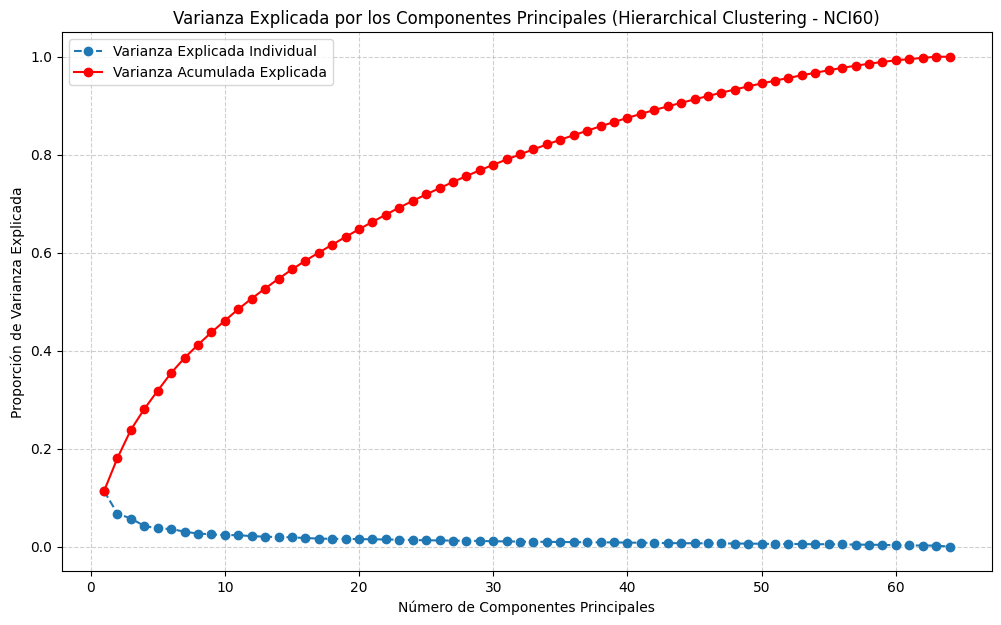

El 90% de la varianza es explicada por 44 componentes.

El 95% de la varianza es explicada por 51 componentes.

El 99% de la varianza es explicada por 60 componentes.


In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA con todos los componentes posibles para analizar la varianza explicada (para Hierarchical Clustering)
pca_full_hierarchical = PCA()
X_pca_full_hierarchical = pca_full_hierarchical.fit_transform(X_scaled)

# Calcular la varianza explicada por cada componente principal
explained_variance_ratio_hierarchical = pca_full_hierarchical.explained_variance_ratio_

# Calcular la varianza acumulada explicada
cumulative_explained_variance_hierarchical = np.cumsum(explained_variance_ratio_hierarchical)

# Crear la gráfica de varianza explicada
plt.figure(figsize=(12, 7))

plt.plot(range(1, len(explained_variance_ratio_hierarchical) + 1), explained_variance_ratio_hierarchical, marker='o', linestyle='--', label='Varianza Explicada Individual')
plt.plot(range(1, len(cumulative_explained_variance_hierarchical) + 1), cumulative_explained_variance_hierarchical, marker='o', linestyle='-', color='red', label='Varianza Acumulada Explicada')

plt.title('Varianza Explicada por los Componentes Principales (Hierarchical Clustering - NCI60)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print(f"El 90% de la varianza es explicada por {np.argmax(cumulative_explained_variance_hierarchical >= 0.90) + 1} componentes.\n")
print(f"El 95% de la varianza es explicada por {np.argmax(cumulative_explained_variance_hierarchical >= 0.95) + 1} componentes.\n")
print(f"El 99% de la varianza es explicada por {np.argmax(cumulative_explained_variance_hierarchical >= 0.99) + 1} componentes.")

PCA aplicado a los datos escalados con 2 componentes.


,Principal Component 1,Principal Component 2,Original Label
0,19.838071,-3.555664,CNS
1,23.089249,-6.442222,CNS
2,27.456133,-2.464398,CNS
3,42.816823,9.769207,RENAL
4,55.418515,5.199904,BREAST


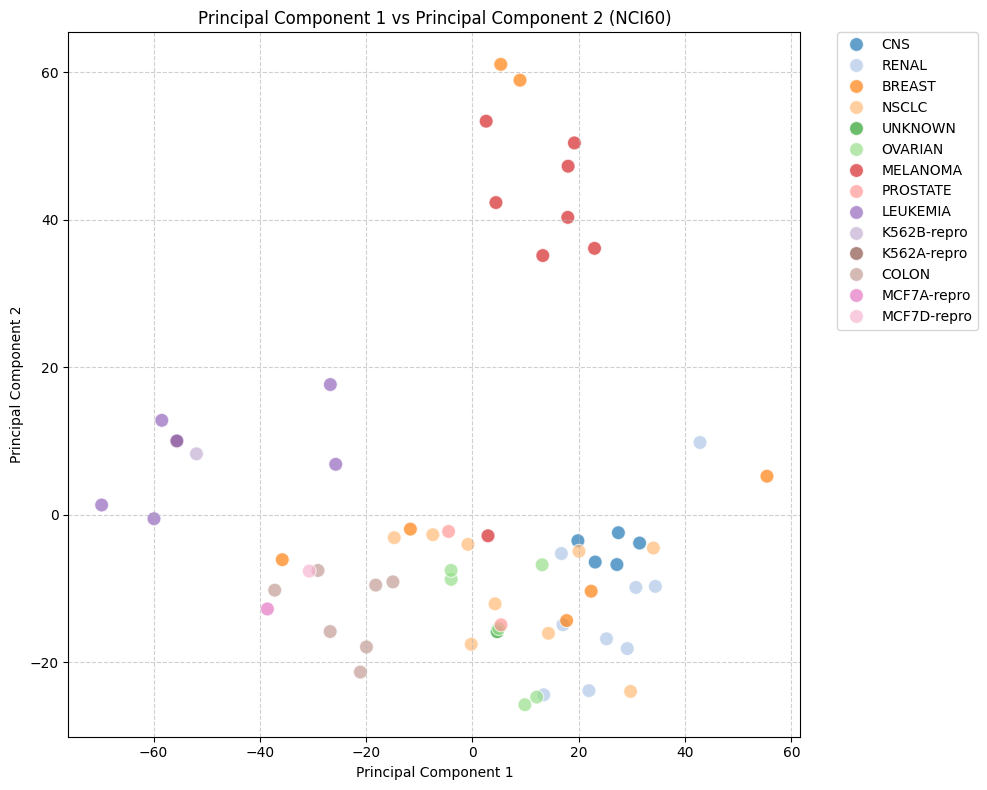

In [47]:
# Aplicar PCA para reducir la dimensionalidad a 2 componentes para visualización (Hierarchical Clustering)
pca_2_components_hierarchical = PCA(n_components=2)
X_pca_2d_hierarchical = pca_2_components_hierarchical.fit_transform(X_scaled)

# Crear un DataFrame para los componentes PCA
df_pca_2d_hierarchical = pd.DataFrame(data = X_pca_2d_hierarchical, columns = ['Principal Component 1', 'Principal Component 2'])

# Añadir las etiquetas originales (y_nci) para colorear los gráficos
df_pca_2d_hierarchical['Original Label'] = y_nci['label']

print("PCA aplicado a los datos escalados con 2 componentes.")
display(df_pca_2d_hierarchical.head())

# Visualizar PC1 vs PC2
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Original Label', data=df_pca_2d_hierarchical, s=100, alpha=0.7, palette='tab20')
plt.title('Principal Component 1 vs Principal Component 2 (NCI60)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

Esto ya lo habíamos calculado y graficado anteriormente y de nuevo, tenemos el 90% de la varianza explicada por 44 componentes, el 95% es explicada por 51 componentes y el 99% por 60 componentes.
De igual manera, con el gráfico de dispersión de los componentes principales 1 y 2 se podrían identificar entre 3 y 5 clusters, pero esta selección resulta muy subjetiva.
Vamos a tomar los 44 componentes principales que explican el 90% de la varianza, así como lo hicimos en el método anterior. Luego, realizaremos el clustering jerárquico. Primero, debemos importar la librería `linkage` y `dendrogram` de `scipy.cluster.hierarchy`. Recordemos que el cluster jerárquico agrupa datos de manera progresiva, creando una especie de árbol, en lugar de dividir en grupos como K-means. Usamos la distancia euclidiana para medir qué tan similares son las muestras, agregando el parámetro `metric='euclidean'`. También agregamos `method='complete'` que es una forma de unir clusters, que es un método más estricto para crear los clusters ya que todos los puntos de un cluster deben estar relativamente cerca de todos los del otro (todo esto se hace dentro de la función `linkage`).
Después, creamos el dendograma (que es como el árbol de los cómo se unen los datos) con la función `dendrogram` con la variable `linkae_matrix_complete` que acabamos de crear con el clustering jerárquico. Para mejor visualización, lo hacemos monocromático con `color_threshold=0` y `above_threshold_color='black'` para asegurarnos que todas las líneas sean negras.
Si en el dendograma se tiene uniones muy altas, los grupos son muy distintos. Por el contrario, si las uniones son bajas, los grupos son muy similares.









PCA aplicado a los datos escalados con 44 componentes para Clustering Jerárquico.
Forma de los datos PCA (44 componentes): (64, 44)


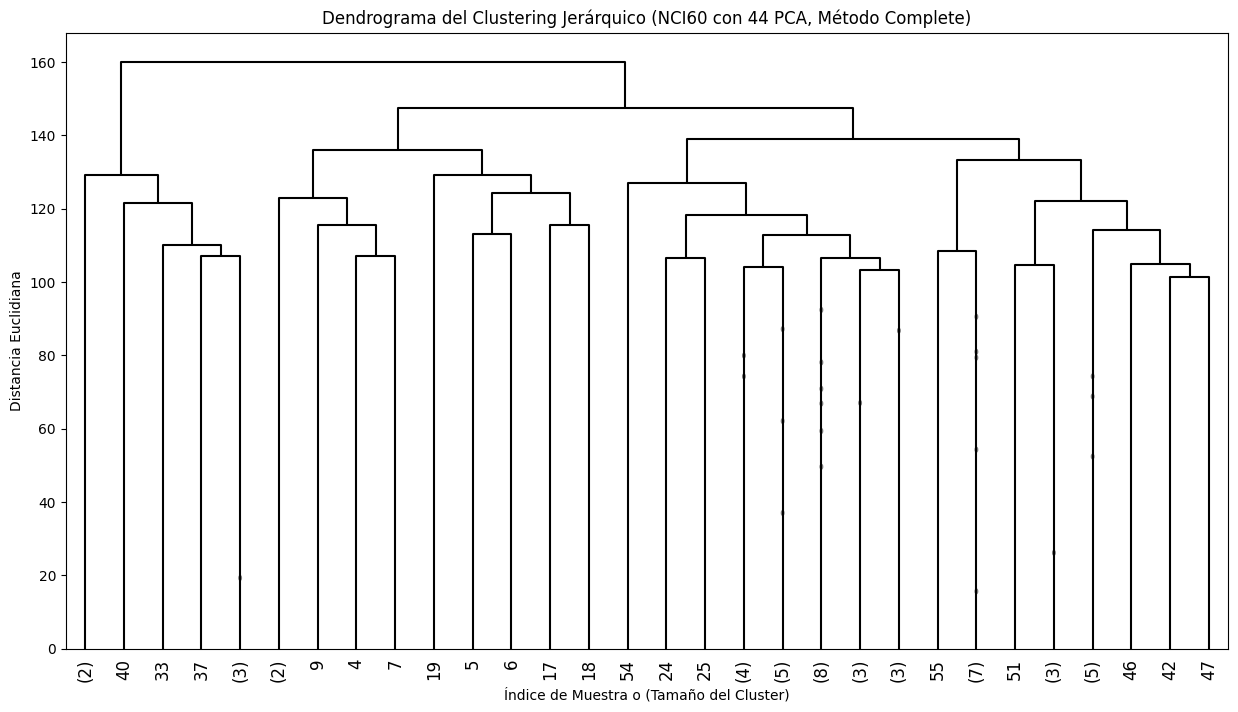

In [49]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Aplicar PCA para reducir la dimensionalidad a 44 componentes (como se decidió anteriormente)
pca_44_components_hierarchical = PCA(n_components=44)
X_pca_44d_hierarchical = pca_44_components_hierarchical.fit_transform(X_scaled)

print("PCA aplicado a los datos escalados con 44 componentes para Clustering Jerárquico.")
print("Forma de los datos PCA (44 componentes):", X_pca_44d_hierarchical.shape)

# Realizar el clustering jerárquico
# Usaremos el método 'complete' y la métrica 'euclidean'
linkage_matrix_complete = linkage(X_pca_44d_hierarchical, method='complete', metric='euclidean')

# Graficar el dendrograma monocromático para visualizar la estructura jerárquica
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix_complete,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    color_threshold=0,  # Esto fuerza un dendrograma monocromático
    above_threshold_color='black' # Esto asegura que todas las líneas sean negras
    # labels=y_nci['label'].values # Puedes descomentar esto si quieres ver las etiquetas originales
)
plt.title('Dendrograma del Clustering Jerárquico (NCI60 con 44 PCA, Método Complete)')
plt.xlabel('Índice de Muestra o (Tamaño del Cluster)')
plt.ylabel('Distancia Euclidiana')
plt.show()

Como podrás ver, hay 2 cluster grandes cuando la distancia euclidiana es de ~160. Por debajo de ~120, tenemos muchos clusters pequeños. Podríamos decir que igual sería conveniente agarrar entre 3 y 5 clusters.

Ahora, vamos a hacer este mismo dendograma policromático, cambiando el threshold de color a diferentes colores para generar 2, 3 y 4 clusters. Vamos a hacer lo mismo que antes pero en `color_threshold` lo cambiaremos a `color_threshold=linkage_matrix_complete[-n, 2]`, donde `n` es el valor de clusters que queremos.

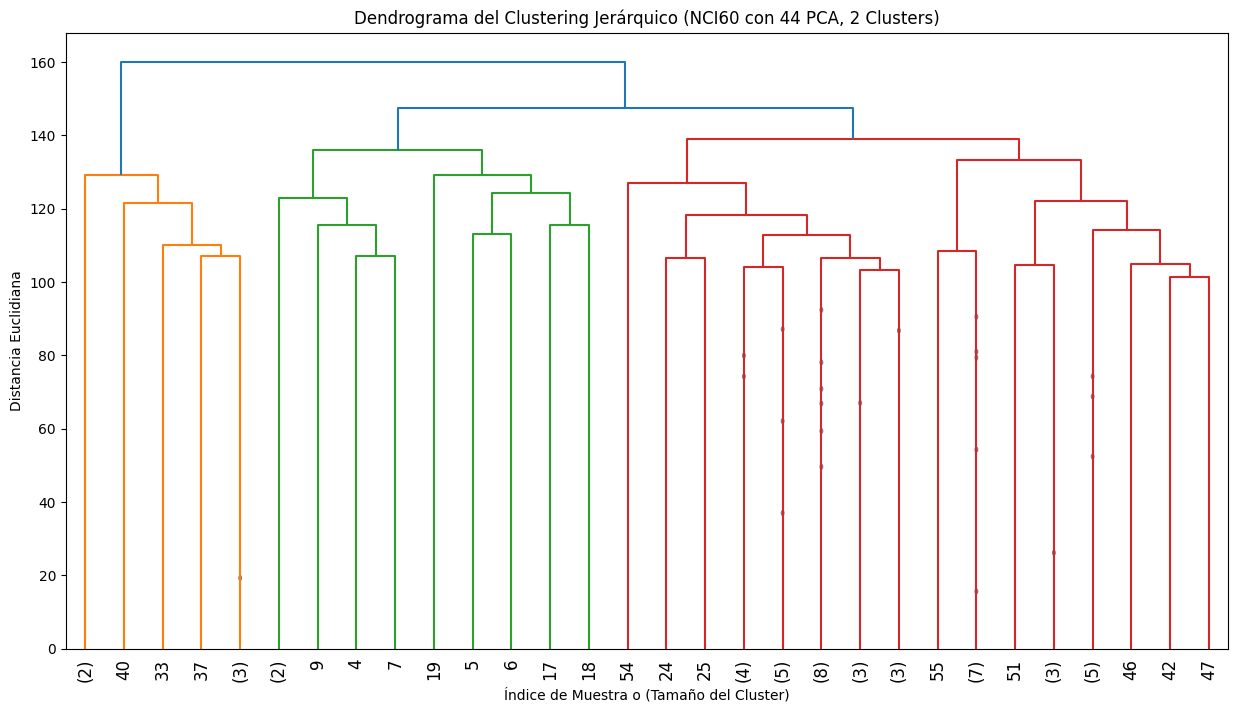

In [57]:
# Graficar el dendrograma para 2 clusters (cambiando el color_threshold)
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix_complete,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    color_threshold=linkage_matrix_complete[-2, 2], # Umbral para 2 clusters
    # labels=y_nci['label'].values
)
plt.title('Dendrograma del Clustering Jerárquico (NCI60 con 44 PCA, 2 Clusters)')
plt.xlabel('Índice de Muestra o (Tamaño del Cluster)')
plt.ylabel('Distancia Euclidiana')
plt.show()

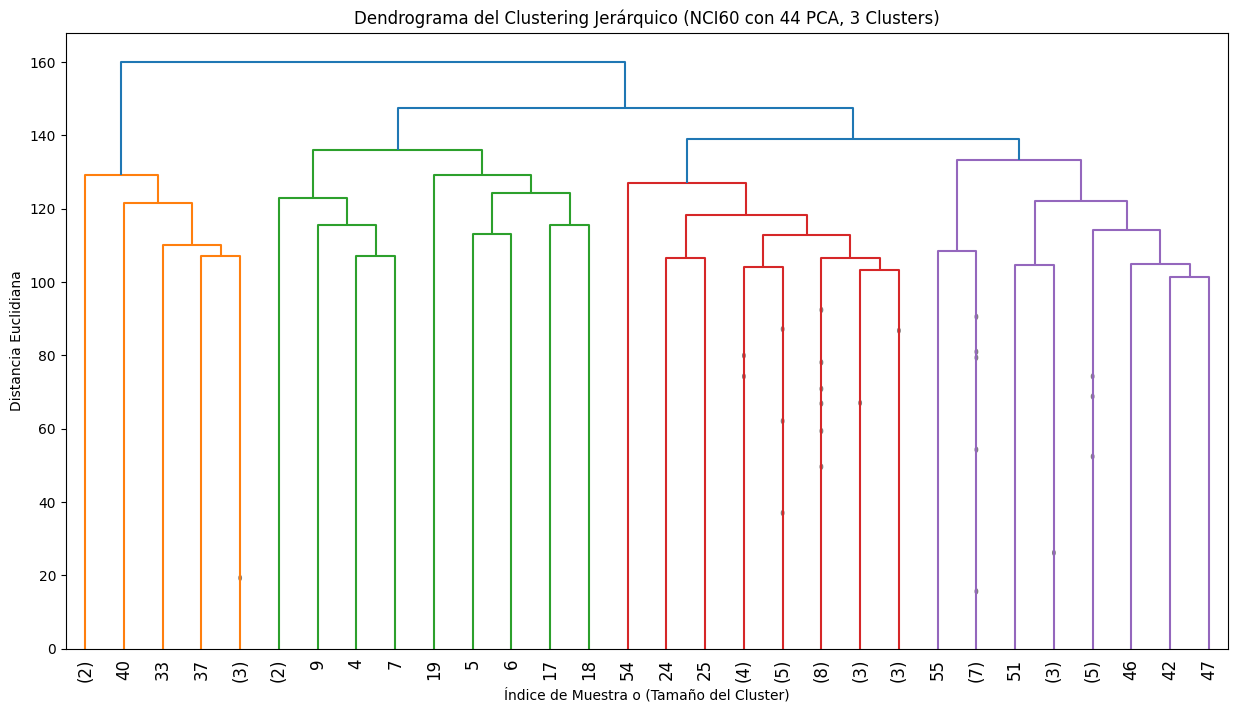

In [51]:
# Graficar el dendrograma para 3 clusters (cambiando el color_threshold)
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix_complete,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    color_threshold=linkage_matrix_complete[-3, 2], # Umbral para 3 clusters
    # labels=y_nci['label'].values
)
plt.title('Dendrograma del Clustering Jerárquico (NCI60 con 44 PCA, 3 Clusters)')
plt.xlabel('Índice de Muestra o (Tamaño del Cluster)')
plt.ylabel('Distancia Euclidiana')
plt.show()

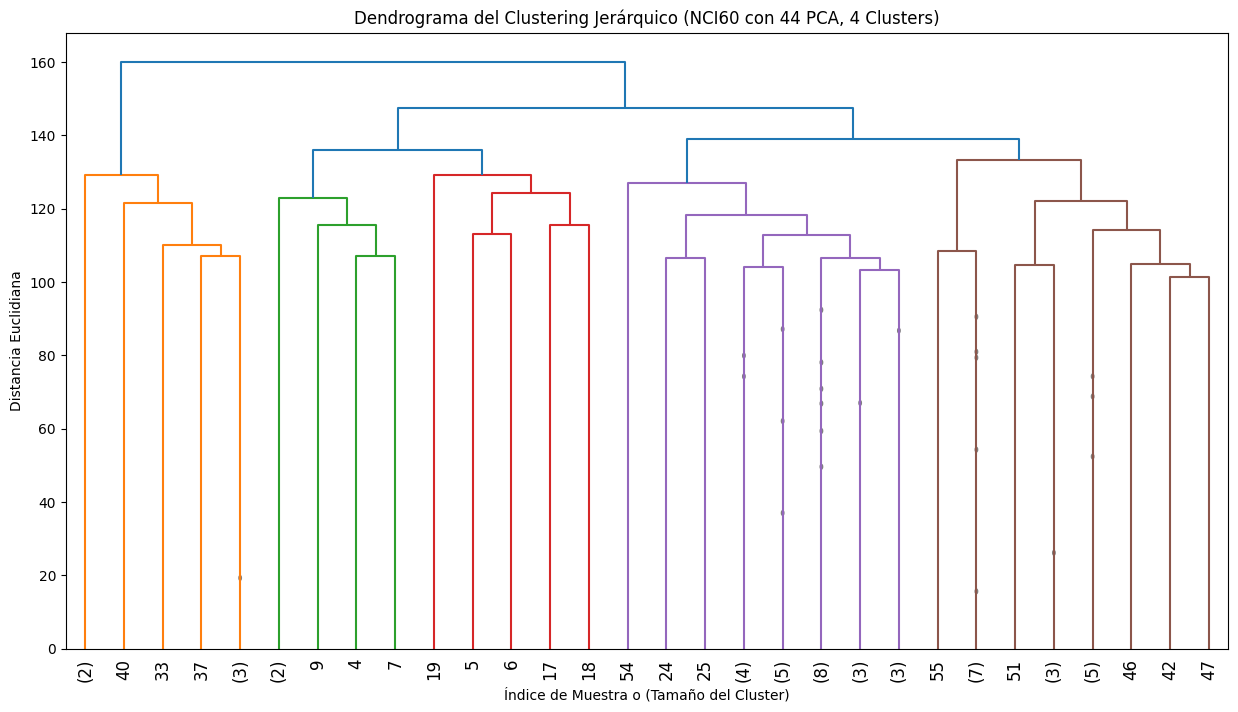

In [52]:
# Graficar el dendrograma para 4 clusters (cambiando el color_threshold)
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix_complete,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    color_threshold=linkage_matrix_complete[-4, 2], # Umbral para 4 clusters
    # labels=y_nci['label'].values
)
plt.title('Dendrograma del Clustering Jerárquico (NCI60 con 44 PCA, 4 Clusters)')
plt.xlabel('Índice de Muestra o (Tamaño del Cluster)')
plt.ylabel('Distancia Euclidiana')
plt.show()

Podrás darte cuenta que cuando se aumenta el número de clusters, se aumentan la cantidad de colores en el dendograma. Estos diagramas sirven para identificar cuántos clusters usar para dividir los datos. Por ejemplo, en el dendograma de 4 clusters, si se agarra una distancia euclidiana de ~130, podríamos decir que podemos dividir los datos en 5 clusters.


Como funciona es que se inicia con n cantidad de observaciones y se hace el cálculo de disimilitud entre todos los pares de observaciones. Se identifica el par de clusters (que cada observación se considera su propio cluster) con menor disimilitud, luego se unen ambos clusters en la misma rama (la métrica de disimilitud señala la altura a la que se mostrarán en el dendograma). Por último se actualizan las métricas de disimilitud usando los *i* - 1 clusters que faltan.


Ahora, vamos a volver a hacer un cluster jerárquico pero cambiando la métrica a correlación. Puedes copiar y pegar el código en donde hicimos esto y sólo cambiar `metric = correlation`, para poder agrupar las muestras en la similitud de los patrones de expresión genética. De igual manera, graficamos el dendograma pero con este nuevo resultado.





PCA aplicado a los datos escalados con 44 componentes para Clustering Jerárquico (Correlación).
Forma de los datos PCA (44 componentes): (64, 44)


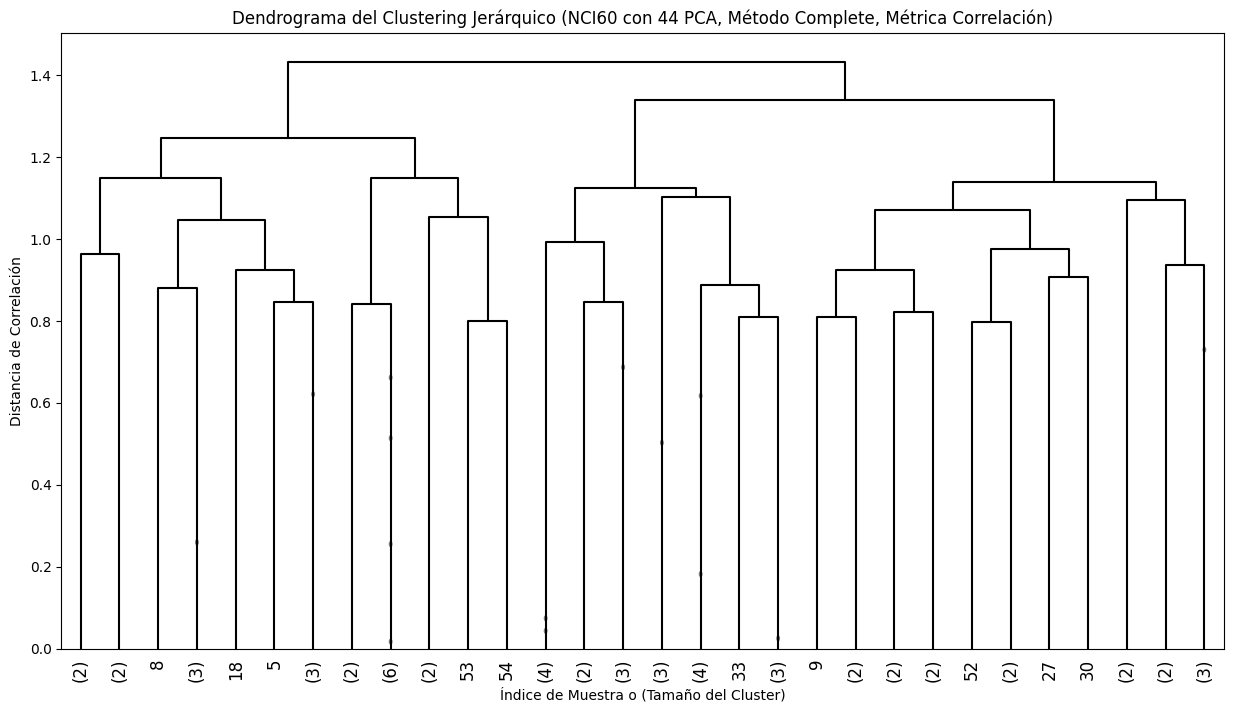

In [58]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA para reducir la dimensionalidad a 44 componentes (manteniendo la consistencia)
pca_44_components_correlation = PCA(n_components=44)
X_pca_44d_correlation = pca_44_components_correlation.fit_transform(X_scaled)

print("PCA aplicado a los datos escalados con 44 componentes para Clustering Jerárquico (Correlación).")
print("Forma de los datos PCA (44 componentes):", X_pca_44d_correlation.shape)

# Realizar el clustering jerárquico con método 'complete' y métrica 'correlation'
linkage_matrix_correlation = linkage(X_pca_44d_correlation, method='complete', metric='correlation')

# Graficar el dendrograma monocromático
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix_correlation,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    color_threshold=0,  # Monocromático
    above_threshold_color='black'
)
plt.title('Dendrograma del Clustering Jerárquico (NCI60 con 44 PCA, Método Complete, Métrica Correlación)')
plt.xlabel('Índice de Muestra o (Tamaño del Cluster)')
plt.ylabel('Correlación')
plt.show()

Si comparamos este dendograma monocromático con el pasado, se parecen mucho. Pero, en este, varias de las uniones están más abajo. Por ejemplo, para una correlación de más de 1.2, se podrían hacer unos 3 o 4 clusters.


El decidir qué métrica usar depende del análisis que se quiere hacer. Para este caso, en donde se quieren identificar patrones biológicos en los genes para poder hacer algo al respecto, convendría más usar la métrica de correlación.


Ahora, vamos a volver a hacer estos cálculos pero con el método `average` y la métrica euclidiana. Después, graficaremos el dendrograma de estos nuevos resultados.
Usa el mismo código que hemos estado usando para estos cálculos, sólo cambia el `method` y `metric`, además de el título del eje `y` en el gráfico. Con el método del promedio se considera la distancia promedio entre todos los puntos de dos clusters para decidir su unión, mientras que la métrica euclidiana mide la distancia directa en el espacio.







PCA aplicado a los datos escalados con 44 componentes para Clustering Jerárquico (Average, Euclidiana).
Forma de los datos PCA (44 componentes): (64, 44)


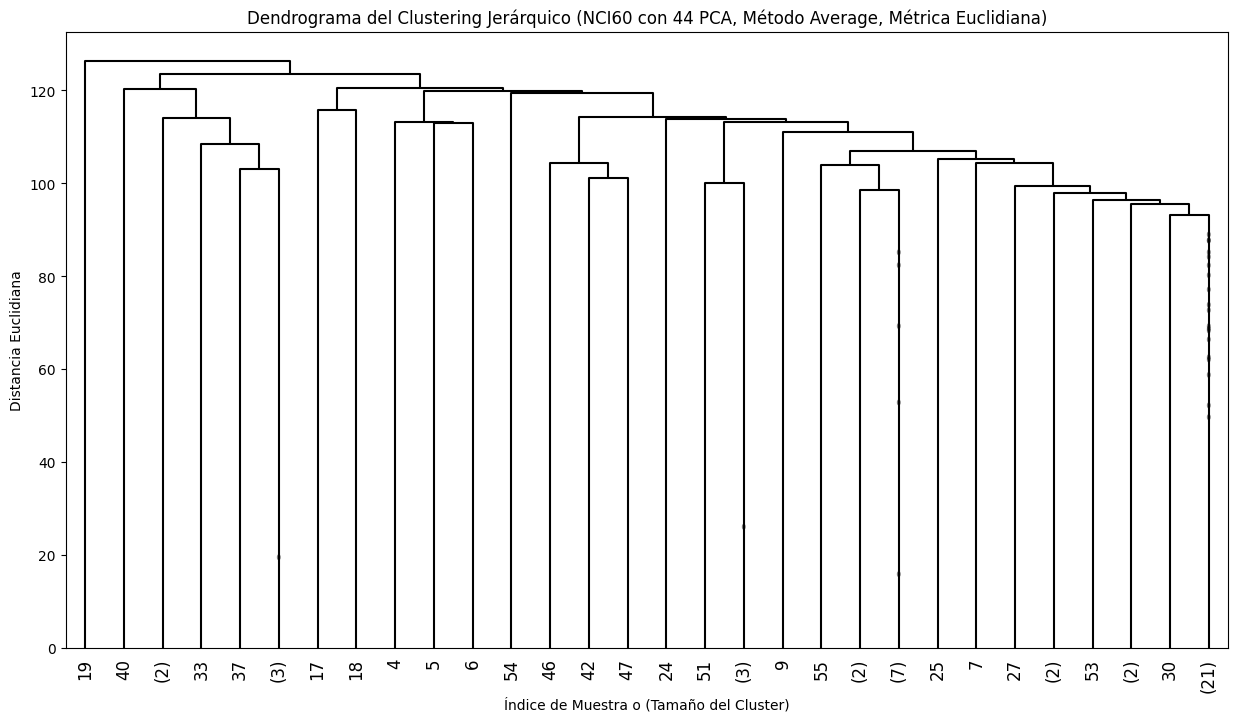

In [59]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA para reducir la dimensionalidad a 44 componentes (manteniendo la consistencia)
pca_44_components_average_euclidean = PCA(n_components=44)
X_pca_44d_average_euclidean = pca_44_components_average_euclidean.fit_transform(X_scaled)

print("PCA aplicado a los datos escalados con 44 componentes para Clustering Jerárquico (Average, Euclidiana).")
print("Forma de los datos PCA (44 componentes):", X_pca_44d_average_euclidean.shape)

# Realizar el clustering jerárquico con método 'average' y métrica 'euclidean'
linkage_matrix_average_euclidean = linkage(X_pca_44d_average_euclidean, method='average', metric='euclidean')

# Graficar el dendrograma monocromático
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix_average_euclidean,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    color_threshold=0,  # Monocromático
    above_threshold_color='black'
)
plt.title('Dendrograma del Clustering Jerárquico (NCI60 con 44 PCA, Método Average, Métrica Euclidiana)')
plt.xlabel('Índice de Muestra o (Tamaño del Cluster)')
plt.ylabel('Distancia Euclidiana')
plt.show()

Con estas especificaciones, con una distancia euclidiana de 120 se pueden crear 2 o 3 clusters. En este gráfico, también se puede ver que con poca diferencia de distancia euclidiana se crean muchos clusters diferentes, a diferencia de los 2 métodos anteriores, donde había más separación entre los cortes.


Con los dendrogramas pudimos visualizar cómo las muestras se agrupan según su similitud. Es importante recalcar que así como en el método anterior, el corte que se elige subjetivamente además de la métrica usada influyen mucho en lo que se obtienen de resultados. Es por eso que ambos métodos vistos en este tutorial deberían usarse como una métodos de exploración y complementarse con más métricas y métodos para poder tomar decisiones definitivas.



